<a href="https://colab.research.google.com/github/MiteshPatole/Master-Thesis/blob/main/ToNIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn.model_selection
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import sklearn.decomposition
import imblearn.over_sampling
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import IncrementalPCA
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
df=pd.read_csv('train_test_network.csv')
df.head()


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [ ]:
df = df.drop('src_ip', axis=1)
df = df.drop('dst_ip', axis=1)
df = df.drop('proto', axis=1)
df = df.drop('conn_state', axis=1)
df = df.drop('service', axis=1)

In [ ]:
df = df.sample(17000)
print("\nMissing values in the dataset")
print(df.isna().sum())


Missing values in the dataset
src_port                  0
dst_port                  0
duration                  0
src_bytes                 0
dst_bytes                 0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code          0
http_user_agent           0
http_orig_mime_types      0
http_resp_mime_types      0
weird_name       

In [ ]:
for column in df.columns:
    unique_values = df[column].unique()
    df.nunique()
    print(f"Unique values in column '{column}': {unique_values}")

Unique values in column 'src_port': [59812 57726 50074 ... 56593 55318 33418]
Unique values in column 'dst_port': [  53   80 8080 ... 1007  256 6123]
Unique values in column 'duration': [5.482000e-03 1.659360e-01 1.030000e-04 ... 3.477956e+00 2.955000e-03
 2.368140e-01]
Unique values in column 'src_bytes': [        74        458          0        130        211         58
        515        191        218        155        303        221
       1510        297        351        336        486        167
         44         41        238        172        147         50
         52        347        430        256       1981         87
         66        153        398        161        286        122
        487        312        277       2581         31       5917
        237        438        276        203        154        226
        506        315        252         84       2251        157
        324        603        215         35        534         83
        239        283

In [ ]:
df.isna().sum()

,0
src_port,0
dst_port,0
duration,0
src_bytes,0
dst_bytes,0
missed_bytes,0
src_pkts,0
src_ip_bytes,0
dst_pkts,0
dst_ip_bytes,0


In [ ]:
x_train = df.drop(["label"],axis = 1)
y_train = df["label"]

x_test = df.drop(["label"],axis=1)
y_test = df["label"]

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (17000, 38)
x_test: (17000, 38)
y_train: (17000,)
y_test: (17000,)


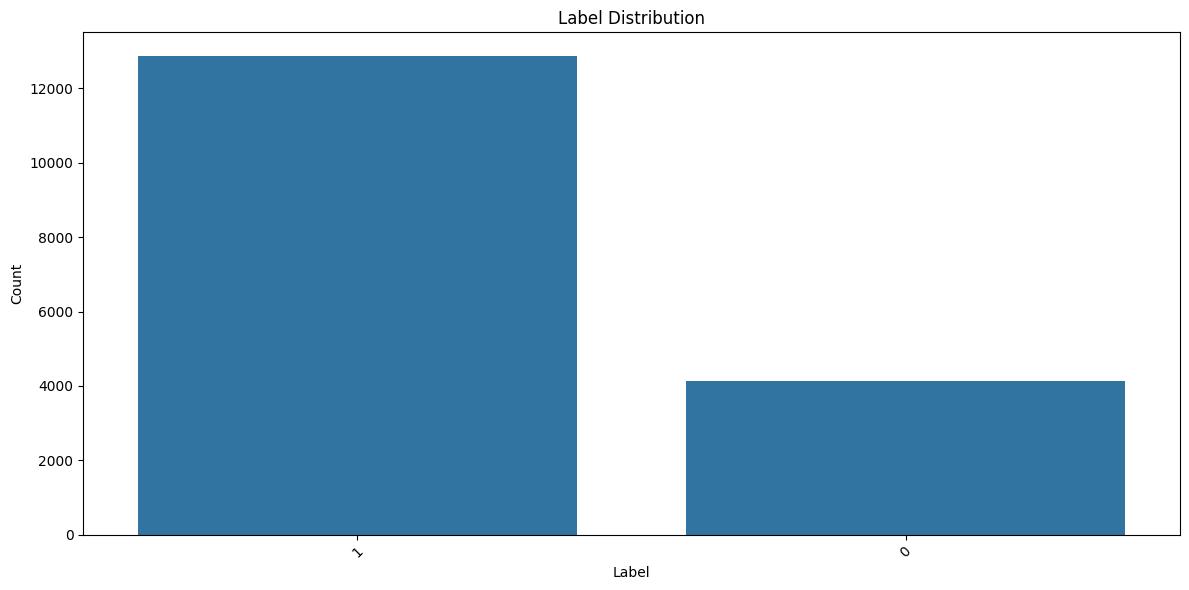

In [ ]:

plt.figure(figsize=(12, 6))
sns.countplot(df, x='label', order=df['label'].value_counts().index)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming x_train and x_test are already defined DataFrames

# Replace '-' with NaN in both training and test data
x_train = x_train.replace('-', np.nan)
x_test = x_test.replace('-', np.nan)

# Convert all columns to numeric (non-convertible values become NaN)
for col in x_train.columns:
    x_train[col] = pd.to_numeric(x_train[col], errors='coerce')
for col in x_test.columns:
    x_test[col] = pd.to_numeric(x_test[col], errors='coerce')

# Fill NaN values with the mean of each column
x_train = x_train.fillna(x_train.mean())
x_test = x_test.fillna(x_test.mean())

# Initialize and apply StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# Optionally, convert the scaled arrays back to DataFrames
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

print("Scaling complete. x_train_scaled and x_test_scaled are ready for use.")


Scaling complete. x_train_scaled and x_test_scaled are ready for use.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:

encoder = OneHotEncoder(handle_unknown='ignore')
x_train_encoded = encoder.fit_transform(x_train)
x_test_encoded = encoder.transform(x_test)

In [ ]:
for column in df.select_dtypes(include=['object']).columns:
    # Convert to numeric, errors become NaN
    df[column] = pd.to_numeric(df[column], errors='coerce')
    # Replace '-' with a specific value, e.g., 0
    df[column] = df[column].replace('-', 0)  # or any other suitable replacement
    # Fill remaining NaN with the mean (or other strategy) if needed
    df[column] = df[column].fillna(df[column].mean())


from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA

# Assuming x_train and x_test are already defined DataFrames

# 1. Replace '-' with NaN
x_train = x_train.replace('-', np.nan)
x_test = x_test.replace('-', np.nan)

# 2. Convert all columns to numeric (non-convertible values become NaN)
for col in x_train.columns:
    x_train[col] = pd.to_numeric(x_train[col], errors='coerce')
for col in x_test.columns:
    x_test[col] = pd.to_numeric(x_test[col], errors='coerce')

# 3. Identify and drop columns with all missing values
cols_all_missing = x_train.columns[x_train.isnull().all()]
print("Dropping columns with all missing values:", list(cols_all_missing))
x_train = x_train.drop(columns=cols_all_missing)
x_test = x_test.drop(columns=cols_all_missing)

# 4. Impute missing values using SimpleImputer with the mean strategy
imputer = SimpleImputer(strategy='mean')
x_train_imputed = pd.DataFrame(imputer.fit_transform(x_train), columns=x_train.columns)
x_test_imputed = pd.DataFrame(imputer.transform(x_test), columns=x_test.columns)

# 5. Determine allowed number of components for IncrementalPCA
n_features = x_train_imputed.shape[1]
n_components = min(24, n_features)  # Ensures n_components does not exceed the number of features
print(f"Using n_components={n_components} for IncrementalPCA (n_features={n_features}).")

# 6. Apply IncrementalPCA
ipca = IncrementalPCA(n_components=n_components, batch_size=200)
x_train_transformed = ipca.fit_transform(x_train_imputed)
x_test_transformed = ipca.transform(x_test_imputed)

print("IncrementalPCA transformation complete.")


Dropping columns with all missing values: ['dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_method', 'http_uri', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_notice', 'type']
Using n_components=19 for IncrementalPCA (n_features=19).
IncrementalPCA transformation complete.


In [ ]:


ros = RandomOverSampler(random_state=42)
x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)
print("x_train_resampled size:", x_train_resampled.shape)
print("y_train_resampled size:", y_train_resampled.shape)

x_train_resampled size: (25734, 19)
y_train_resampled size: (25734,)


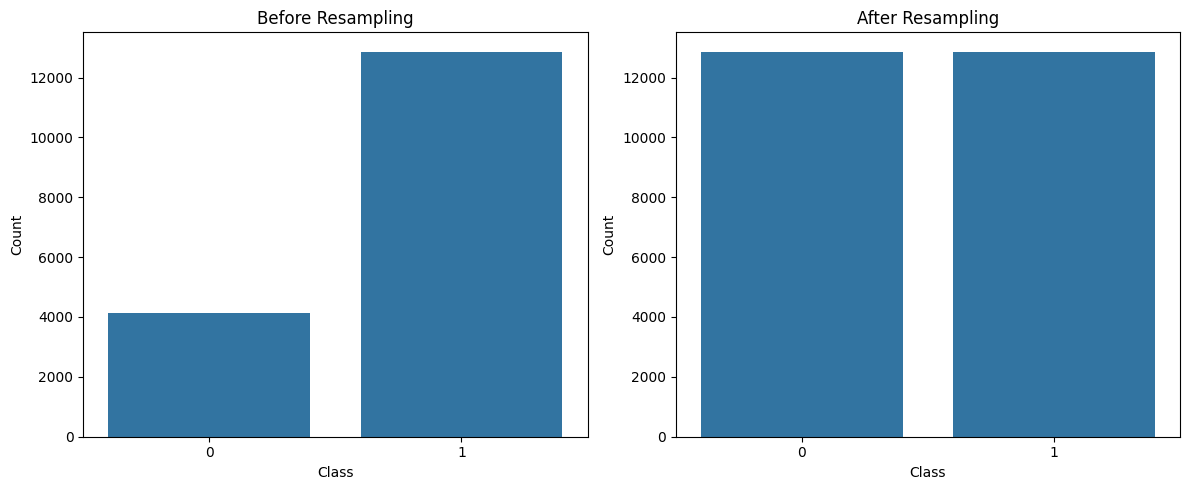

In [ ]:



counts_before = pd.Series(y_train).value_counts().sort_index()
counts_after = pd.Series(y_train_resampled).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.barplot(x=counts_before.index, y=counts_before.values, ax=axes[0])
axes[0].set_title("Before Resampling")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")


sns.barplot(x=counts_after.index, y=counts_after.values, ax=axes[1])
axes[1].set_title("After Resampling")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:


# Define a simplified parameter grid
parameters_ranfor = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [10, 15]
}

# Initialize the RandomForestClassifier
model_ranfor = RandomForestClassifier(random_state=42)

# Use a subset of the resampled training data for faster tuning
subset_size = 10000  # Use 10,000 samples for hyperparameter tuning
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]

# Set up RandomizedSearchCV with fewer iterations and verbose output
clf_model_ranfor = RandomizedSearchCV(
    model_ranfor,
    parameters_ranfor,
    scoring="accuracy",
    cv=3,           # 3-fold cross-validation
    n_jobs=-1,      # Use all available cores
    n_iter=5,       # Fewer iterations for speed
    random_state=42,
    verbose=2       # Verbose output to monitor progress
)

start_time = time.time()
clf_model_ranfor.fit(x_subset, y_subset)
elapsed_time = time.time() - start_time

print("Elapsed time: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best Random Forest Classifier = {:.2f}".format(clf_model_ranfor.best_score_))
print("Best found hyperparameters = {}".format(clf_model_ranfor.best_params_))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Elapsed time: 8.65 seconds
Accuracy of best Random Forest Classifier = 0.99
Best found hyperparameters = {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}


In [ ]:
y_predicted=clf_model_ranfor.predict(x_test)
accuracy=sklearn.metrics.accuracy_score(y_test,y_predicted)
cm=sklearn.metrics.confusion_matrix(y_test,y_predicted)
precision,recall,f1,support=sklearn.metrics.precision_recall_fscore_support(y_test,y_predicted)

print("Accuracy =",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1-score",f1)
print("Confusion Matrix:\n",cm)

Accuracy = 0.9967647058823529
Precision [0.99683236 0.99674318]
Recall [0.98983789 0.99898966]
F1-score [0.99332281 0.99786516]
Confusion Matrix:
 [[ 4091    42]
 [   13 12854]]


In [ ]:
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Optionally reduce the parameter grid to only linear if RBF is too slow:
parameters_svm = {
    'C': [0.01, 0.1, 10, 20],
    'kernel': ['rbf', 'linear']  # Remove 'rbf' if speed is critical
}

# Initialize the SVM model with probability enabled
model_svm = SVC(probability=True, random_state=42)

# Set up GridSearchCV using 2-fold CV for speed and all available cores
clf_model_svm = GridSearchCV(
    model_svm,
    parameters_svm,
    cv=2,           # Reduced number of folds
    n_jobs=-1,      # Use all available cores
    verbose=2
)

# Use a smaller subset for tuning (e.g., 1000 samples)
subset_size = 1000
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]

# Scale the subset
scaler = StandardScaler()
x_subset_scaled = scaler.fit_transform(x_subset)

start_time = time.time()
clf_model_svm.fit(x_subset_scaled, y_subset)
elapsed_time = time.time() - start_time


Fitting 2 folds for each of 8 candidates, totalling 16 fits


In [ ]:
y_predicted=clf_model_ranfor.predict(x_test)
accuracy=sklearn.metrics.accuracy_score(y_test,y_predicted)
cm=sklearn.metrics.confusion_matrix(y_test,y_predicted)
precision,recall,f1,support=sklearn.metrics.precision_recall_fscore_support(y_test,y_predicted)

print("Accuracy =",accuracy)
print("Precision",precision)
print("Recall",recall)
print("F1-score",f1)
print("Confusion Matrix:\n",cm)

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler


parameters_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}


model_knn = KNeighborsClassifier()


clf_model_knn = GridSearchCV(
    model_knn,
    parameters_knn,
    cv=2,
    n_jobs=-1,
    verbose=2
)


subset_size = 1000
x_subset = x_train_resampled[:subset_size]
y_subset = y_train_resampled[:subset_size]


scaler_knn = StandardScaler()
x_subset_scaled = scaler_knn.fit_transform(x_subset)

start_time = time.time()
clf_model_knn.fit(x_subset_scaled, y_subset)
elapsed_time = time.time() - start_time

print("Elapsed time for KNN: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best KNN Classifier = {:.2f}".format(clf_model_knn.best_score_))
print("Best found hyperparameters for KNN = {}".format(clf_model_knn.best_params_))


In [ ]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV


parameters_tree = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}


model_tree = DecisionTreeClassifier(random_state=42)


clf_model_tree = GridSearchCV(
    model_tree,
    parameters_tree,
    cv=2,
    n_jobs=-1,
    verbose=2
)


subset_size = 1000
x_subset_tree = x_train_resampled[:subset_size]
y_subset_tree = y_train_resampled[:subset_size]

start_time = time.time()
clf_model_tree.fit(x_subset_tree, y_subset_tree)
elapsed_time = time.time() - start_time

print("Elapsed time for Decision Tree: {:.2f} seconds".format(elapsed_time))
print("Accuracy of best Decision Tree Classifier = {:.2f}".format(clf_model_tree.best_score_))
print("Best found hyperparameters for Decision Tree = {}".format(clf_model_tree.best_params_))


In [ ]:
# prompt: graph for the accuracy of all models

import matplotlib.pyplot as plt

# Assuming you have the accuracy scores for each model stored in a list or dictionary
model_names = ['Random Forest', 'SVM', 'KNN', 'Decision Tree']
accuracies = [clf_model_ranfor.best_score_, clf_model_svm.best_score_, clf_model_knn.best_score_, clf_model_tree.best_score_]


plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Different Models")
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for accuracy
plt.show()
